# Chromosome IV - Combined Replication Profile Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [56]:
from src.CombinedReplicationDeconvolution import CombinedReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

config1, config2 = load_default_chrom_configs()

combined_deconv = CombinedReplicationDeconvolution(config1=config1, config2=config2,
    chr=4)

Threshold windows with less than 75% read coverage.
Threshold windows with less than 75% read coverage.


In [57]:
config1.shift_parameters_for_alpha()
config2.shift_parameters_for_alpha()

In [71]:
config1.params_dic.update({
    'gamma1': 0.7,
    'gamma2': 1.0,
    'mu0': 14.9,
    'delta': 15.1,
    'lambda': 60
})
config1.update_timepoints()

config2.params_dic.update({
    'gamma1': 0.7,
    'gamma2': 1.0,
    'mu0': 20,
    'delta': 9,
    'lambda': 60
})
config2.update_timepoints()

In [72]:
combined_deconv.setup_deconvolution()

Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0


In [76]:
print("Running initial combined deconvolution for F, N, and B")
result = combined_deconv.iterative_deconvolution_updates(20, verbose=True)

Running initial combined deconvolution for F, N, and B
Iteration 0
0/700 - 00:00:00.025
100/700 - 00:00:00.187
200/700 - 00:00:00.314
300/700 - 00:00:00.433
400/700 - 00:00:00.545
500/700 - 00:00:00.661
600/700 - 00:00:00.782
Iteration completed 00:00:01.473, rn=0.0035929317211457956
Iteration 1
0/700 - 00:00:01.476
100/700 - 00:00:01.590
200/700 - 00:00:01.705
300/700 - 00:00:01.819
400/700 - 00:00:01.931
500/700 - 00:00:02.043
600/700 - 00:00:02.157
Iteration completed 00:00:02.716, rn=0.0035927286245108015
Iteration 2
0/700 - 00:00:02.719
100/700 - 00:00:02.841
200/700 - 00:00:02.983
300/700 - 00:00:03.101
400/700 - 00:00:03.213
500/700 - 00:00:03.328
600/700 - 00:00:03.444
Iteration completed 00:00:03.840, rn=0.003592499708539301
Iteration 3
0/700 - 00:00:03.844
100/700 - 00:00:03.958
200/700 - 00:00:04.078
300/700 - 00:00:04.201
400/700 - 00:00:04.315
500/700 - 00:00:04.439
600/700 - 00:00:04.556
Iteration completed 00:00:04.851, rn=0.003592460407989303
Iteration 4
0/700 - 00:00:0

In [74]:
combined_deconv.rn

0.0035929317211457956

In [65]:
combined_deconv.rn

0.003769479886044947

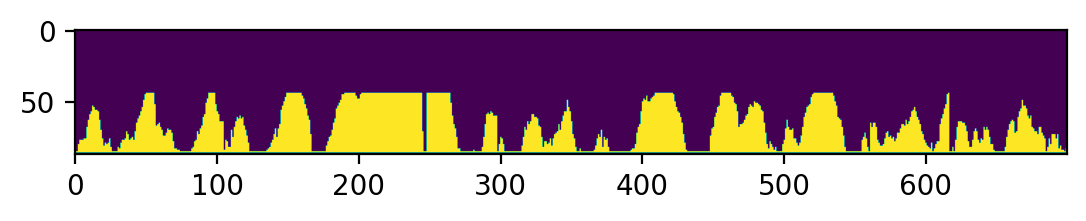

In [77]:
plt.imshow(result.Fs[-1])

In [52]:
epoch_results = combined_deconv.run_epochs(5)

Epoch: 0
[0]: Running H optimizer for replicate 1
Optimization [1]: Current loss: 0.006366105872397624
Optimization [101]: Current loss: 0.006244419879875915
Optimization [201]: Current loss: 0.006240783369771324
Optimization [301]: Current loss: 0.006239888015024112
Optimization terminated successfully.
         Current function value: 0.006240
         Iterations: 216
         Function evaluations: 328
[0]: Running H optimizer for replicate 2
Optimization [1]: Current loss: 0.003712467995344903
Optimization [101]: Current loss: 0.003701122679761926
Optimization [201]: Current loss: 0.0037004691576196197
Optimization terminated successfully.
         Current function value: 0.003700
         Iterations: 166
         Function evaluations: 256
[0]: Done.
[0]: Running iterative updates and combined deconvolution for F, N, and B
00:02:05.283
mu0_1         -1.336088
lambda_1      74.783963
delta_1        0.014744
sigma0_1       4.425889
sigmav_1       0.111217
gamma1_1       0.306319
gamma

In [54]:
combined_deconv.real_deconv1.plot_heatmaps()

AttributeError: 'RealDataReplicationDeconvolution' object has no attribute 'N'

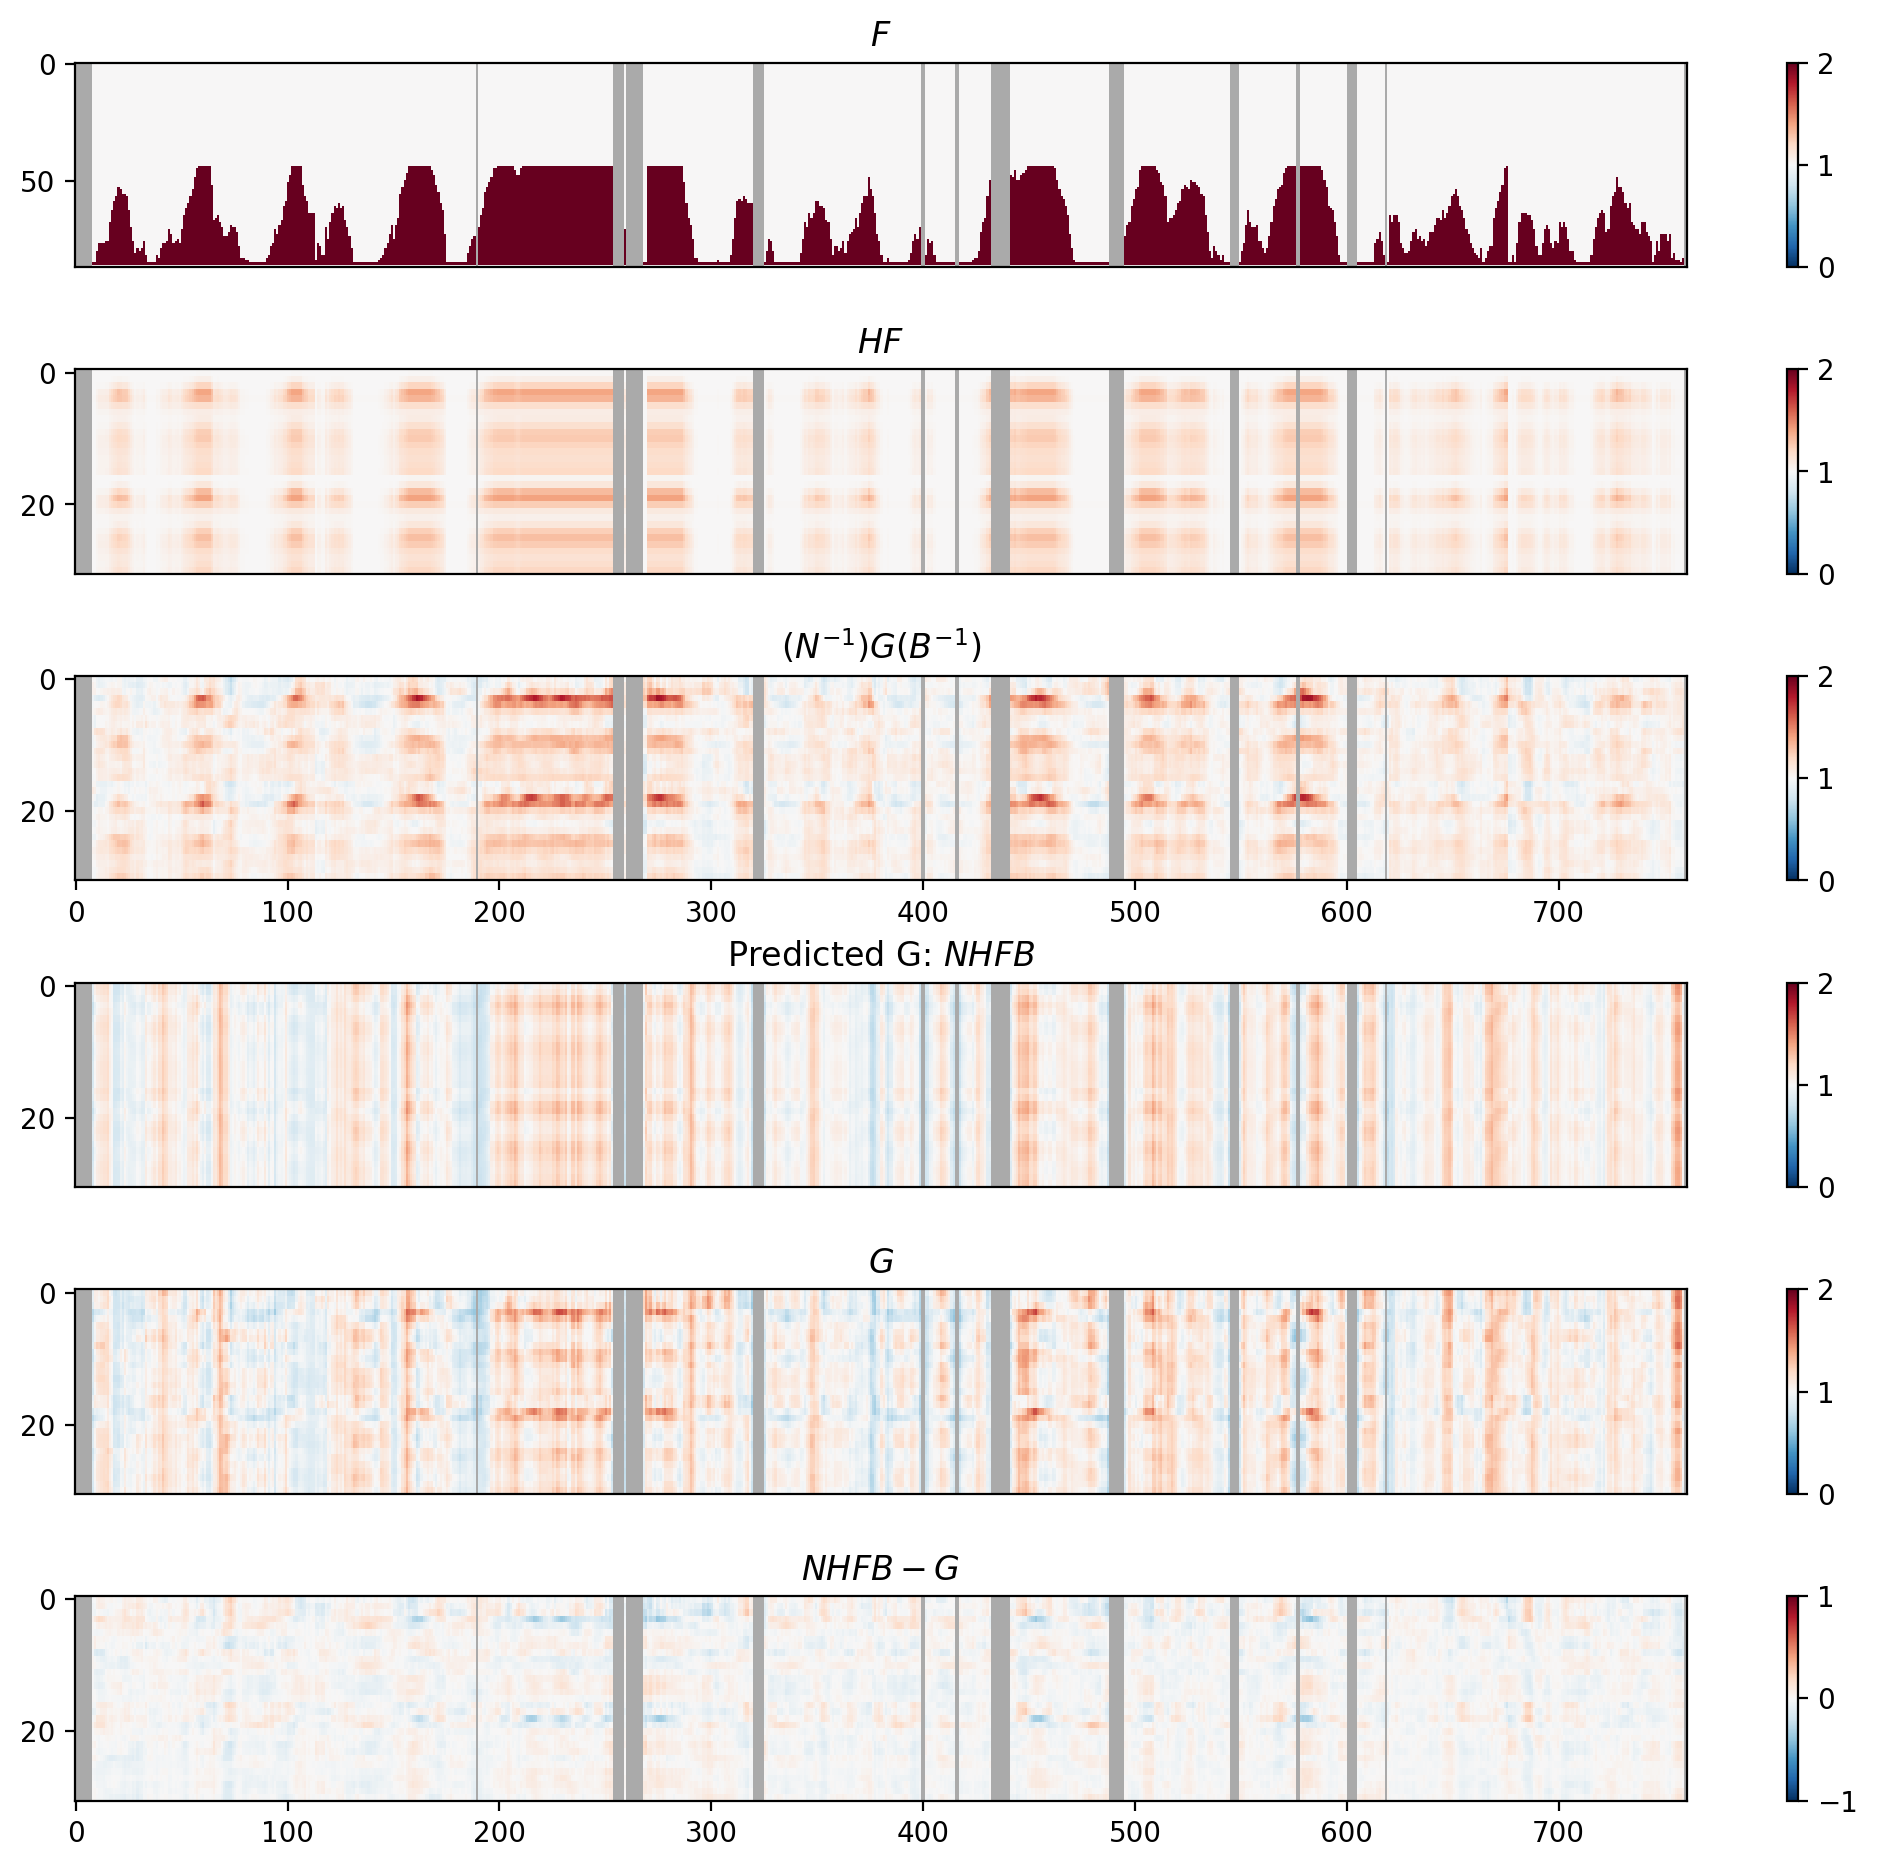

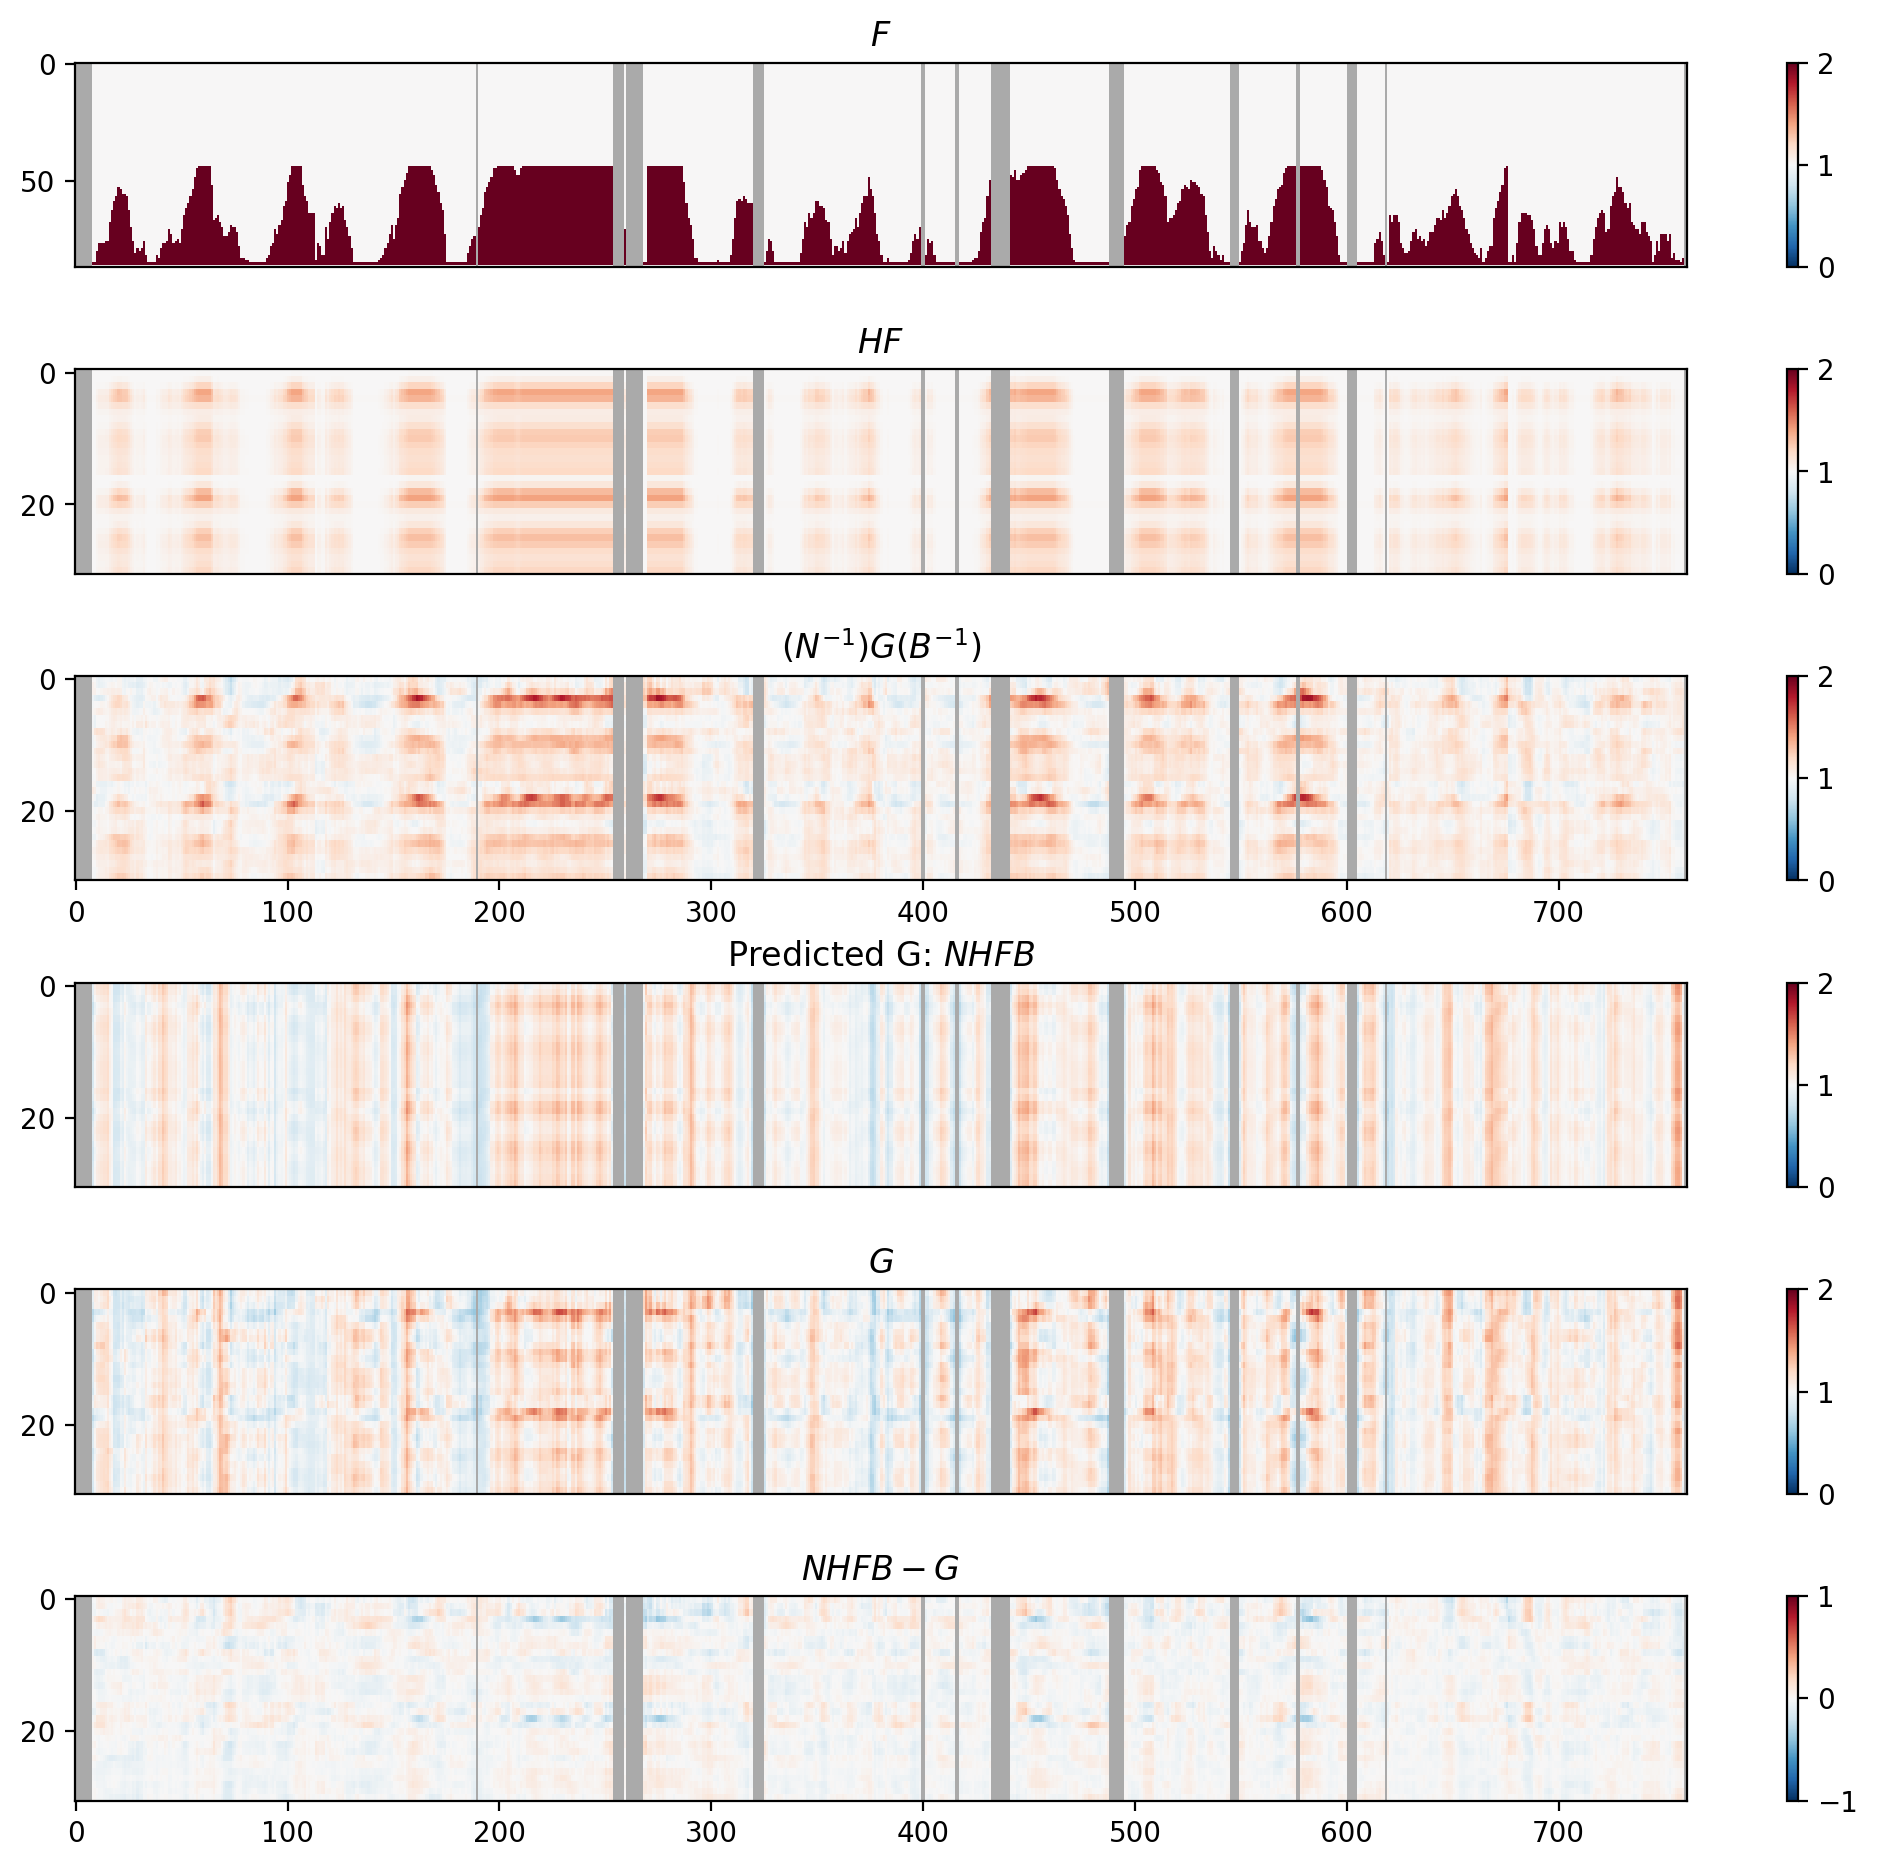

In [78]:
combined_deconv.plot_heatmaps()